# RAMSES Movie Map Viewer

Notebook for inspecting RAMSES `movie*` map outputs like `dens_00424.map`, `vx_00424.map`, etc.

It uses `utils/py/miniramses.py::rd_map` for reading and provides:
- single-frame plotting
- interactive frame browsing
- optional inline animation
- optional `amr2vid.py` command generation for MP4 output


In [27]:
%matplotlib inline

from pathlib import Path
import re
import sys
import subprocess

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

sys.path.append("../utils/py")

import miniramses as ram


In [28]:
# Edit these for your run
movie_dir = Path("/home/jl4415/mini-ramses/coeur_fmm/movie1/")  # e.g. Path("/scratch/.../movie1")
variable = "dens"                 # "dens", "vx", "vy", "vz", "temp", ...
use_log = True
cmap = "inferno"
vmin = None
vmax = None


In [29]:
def discover_map_files(movie_dir: Path, variable: str):
    movie_dir = Path(movie_dir)
    pattern = re.compile(rf"^{re.escape(variable)}_(\d+)\.map$")
    records = []
    for p in movie_dir.glob(f"{variable}_*.map"):
        m = pattern.match(p.name)
        if m:
            records.append((int(m.group(1)), p))
    records.sort(key=lambda x: x[0])
    return records

map_records = discover_map_files(movie_dir, variable)
if not map_records:
    raise FileNotFoundError(f"No files matching {variable}_*.map in {movie_dir}")

frame_numbers = [n for n, _ in map_records]
map_files = [p for _, p in map_records]

print(f"Found {len(map_files)} files for '{variable}' in {movie_dir}")
print(f"First frame number: {frame_numbers[0]:05d}")
print(f"Last frame number:  {frame_numbers[-1]:05d}")
print(f"Example file:       {map_files[0]}")


Found 5 files for 'dens' in /home/jl4415/mini-ramses/coeur_fmm/movie1
First frame number: 00001
Last frame number:  00005
Example file:       /home/jl4415/mini-ramses/coeur_fmm/movie1/dens_00001.map


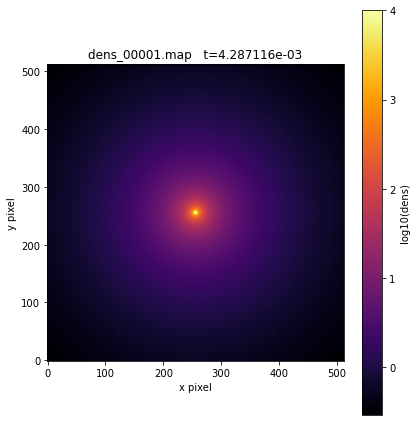

In [30]:
def read_frame(idx: int):
    m = ram.rd_map(str(map_files[idx]))
    data = np.array(m.data, copy=False)
    if use_log:
        data = np.log10(np.maximum(data, 1e-30))
    return m, data

def plot_frame(idx: int, figsize=(6, 6), save=False, out_dir=None):
    idx = int(np.clip(idx, 0, len(map_files) - 1))
    frame_no = frame_numbers[idx]
    m, data = read_frame(idx)

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(data.T, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    cbar_label = f"log10({variable})" if use_log else variable
    plt.colorbar(im, ax=ax, label=cbar_label)
    ax.set_title(f"{variable}_{frame_no:05d}.map   t={m.time:.6e}")
    ax.set_xlabel("x pixel")
    ax.set_ylabel("y pixel")
    plt.tight_layout()

    if save:
        if out_dir is None:
            out_dir = movie_dir / "notebook_frames"
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)
        out = out_dir / f"{variable}_{frame_no:05d}.png"
        fig.savefig(out, dpi=140)
        print(f"Saved {out}")

    return fig, ax

# Example: plot first frame
plot_frame(0)
plt.show()


In [25]:
# Interactive browser (requires ipywidgets)
try:
    import ipywidgets as widgets
    widgets.interact(plot_frame, idx=(0, len(map_files) - 1, 1));
except ImportError:
    print("ipywidgets not installed. Install with: pip install ipywidgets")


ValueError: None cannot be transformed to a widget

In [26]:
# Optional: inline animation preview (for quick inspection)
def make_animation(step=1, max_frames=120, interval_ms=80):
    idxs = list(range(0, len(map_files), max(1, int(step))))[:max_frames]
    if not idxs:
        raise ValueError("No frames selected")

    m0, d0 = read_frame(idxs[0])
    fig, ax = plt.subplots(figsize=(6, 6))
    im = ax.imshow(d0.T, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    cbar_label = f"log10({variable})" if use_log else variable
    plt.colorbar(im, ax=ax, label=cbar_label)
    title = ax.set_title(f"{variable}_{frame_numbers[idxs[0]]:05d}.map   t={m0.time:.6e}")

    def update(j):
        idx = idxs[j]
        m, d = read_frame(idx)
        im.set_data(d.T)
        title.set_text(f"{variable}_{frame_numbers[idx]:05d}.map   t={m.time:.6e}")
        return im, title

    ani = FuncAnimation(fig, update, frames=len(idxs), interval=interval_ms, blit=False)
    plt.close(fig)
    return ani

ani = make_animation(step=5, max_frames=120, interval_ms=70)
HTML(ani.to_jshtml())


In [16]:
# Optional: build MP4 with amr2vid.py (same logic as CLI tool)
start = frame_numbers[0]
end = frame_numbers[-1]
output_mp4 = movie_dir / f"{variable}.mp4"

cmd = [
    sys.executable,
    str(repo_root / "utils/py/amr2vid.py"),
    str(start),
    str(end),
    "--mode", "map",
    "--variable", variable,
    "--movie-dir", str(movie_dir),
    "--col", cmap,
    "--output", str(output_mp4),
    "--keep-frames",
]
if use_log:
    cmd.append("--log")

print("Command:")
print(" ".join(cmd))

# Uncomment to execute
# subprocess.run(cmd, check=True)


Command:
/usr/licensed/anaconda3/2021.11/bin/python /Users/jylee/Ramses-FMM/utils/py/amr2vid.py 1 1598 --mode map --variable dens --movie-dir /home/jl4415/mini-ramses/coeur_mg/movie1 --col inferno --output /home/jl4415/mini-ramses/coeur_mg/movie1/dens.mp4 --keep-frames --log
